In [2]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import time
from tqdm import tqdm
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [4]:
import RW_helpers as RH
import Zernike_helpers as ZH
import Plot_helpers as PH
import Img_helpers as IH
import Booth_helpers as BH

In [5]:
N_order = 3                 # 3 for 3P, 2 for 2P
lambd = 1.3/1000            # Wavelength [mm]
n = 1.3225                  # Refractive index
num_apt = 1.05              # Numerical aperture
length = 200                #mm
mag = 25                    # Magnification rate from input to objective
fwhm_pupil = 8.24           #mm 

L_ffp = 0.004               #size of the psf image
res = 0.05/1000             #resolution of the psf image
theta_grid_size = 90        #number of sampling points (square) in theta/phi grid

In [175]:
microscope = BH.Microscope(N_order, lambd, n, num_apt, length,
                           mag, fwhm_pupil, L_ffp, res, theta_grid_size)
x_img, y_img, single_fluoro_image = IH.bead_img(L_ffp, res, [0], [0], [0.0002])
innate_modes = np.array([[3,3]])
innate_strengths = np.array([0.5])

In [184]:
slm = BH.SLM(microscope, x_img, y_img, single_fluoro_image, innate_modes, innate_strengths)

In [185]:
slm_output_data, quality_data, new_corrections = slm.run_booth(4)

===== Running Booth 2002 Modal AO Algorithm =====
No specific modes inputted. Assuming all modes should be corrected.
Original Aberration:
m=3, n=3: 0.5
===== Iteration 1=====
Getting unbiased image at: m=3, n=3: 0.0
Image Quality: 1.0
Applying biases: 0.2 waves
	===Optimizing m=3, n=3===
	Exploring plus bias...
	Image Quality: 0.82
	Exploring minus bias...
	Image Quality: 1.182
	Evaluating next step...
	Stepping by -0.227 to -0.227
Applying corrections...
===== Iteration 2=====
Getting unbiased image at: m=3, n=3: -0.227
Image Quality: 1.202
Applying biases: 0.16 waves
	===Optimizing m=3, n=3===
	Exploring plus bias...
	Image Quality: 1.065
	Exploring minus bias...
	Image Quality: 1.285
	Evaluating next step...
	Stepping by -0.172 to -0.399
Applying corrections...
===== Iteration 3=====
Getting unbiased image at: m=3, n=3: -0.399
Image Quality: 1.289
Applying biases: 0.128 waves
	===Optimizing m=3, n=3===
	Exploring plus bias...
	Image Quality: 1.231
	Exploring minus bias...
	Image Qu

<string>:9: RuntimeWarning: invalid value encountered in arcsin


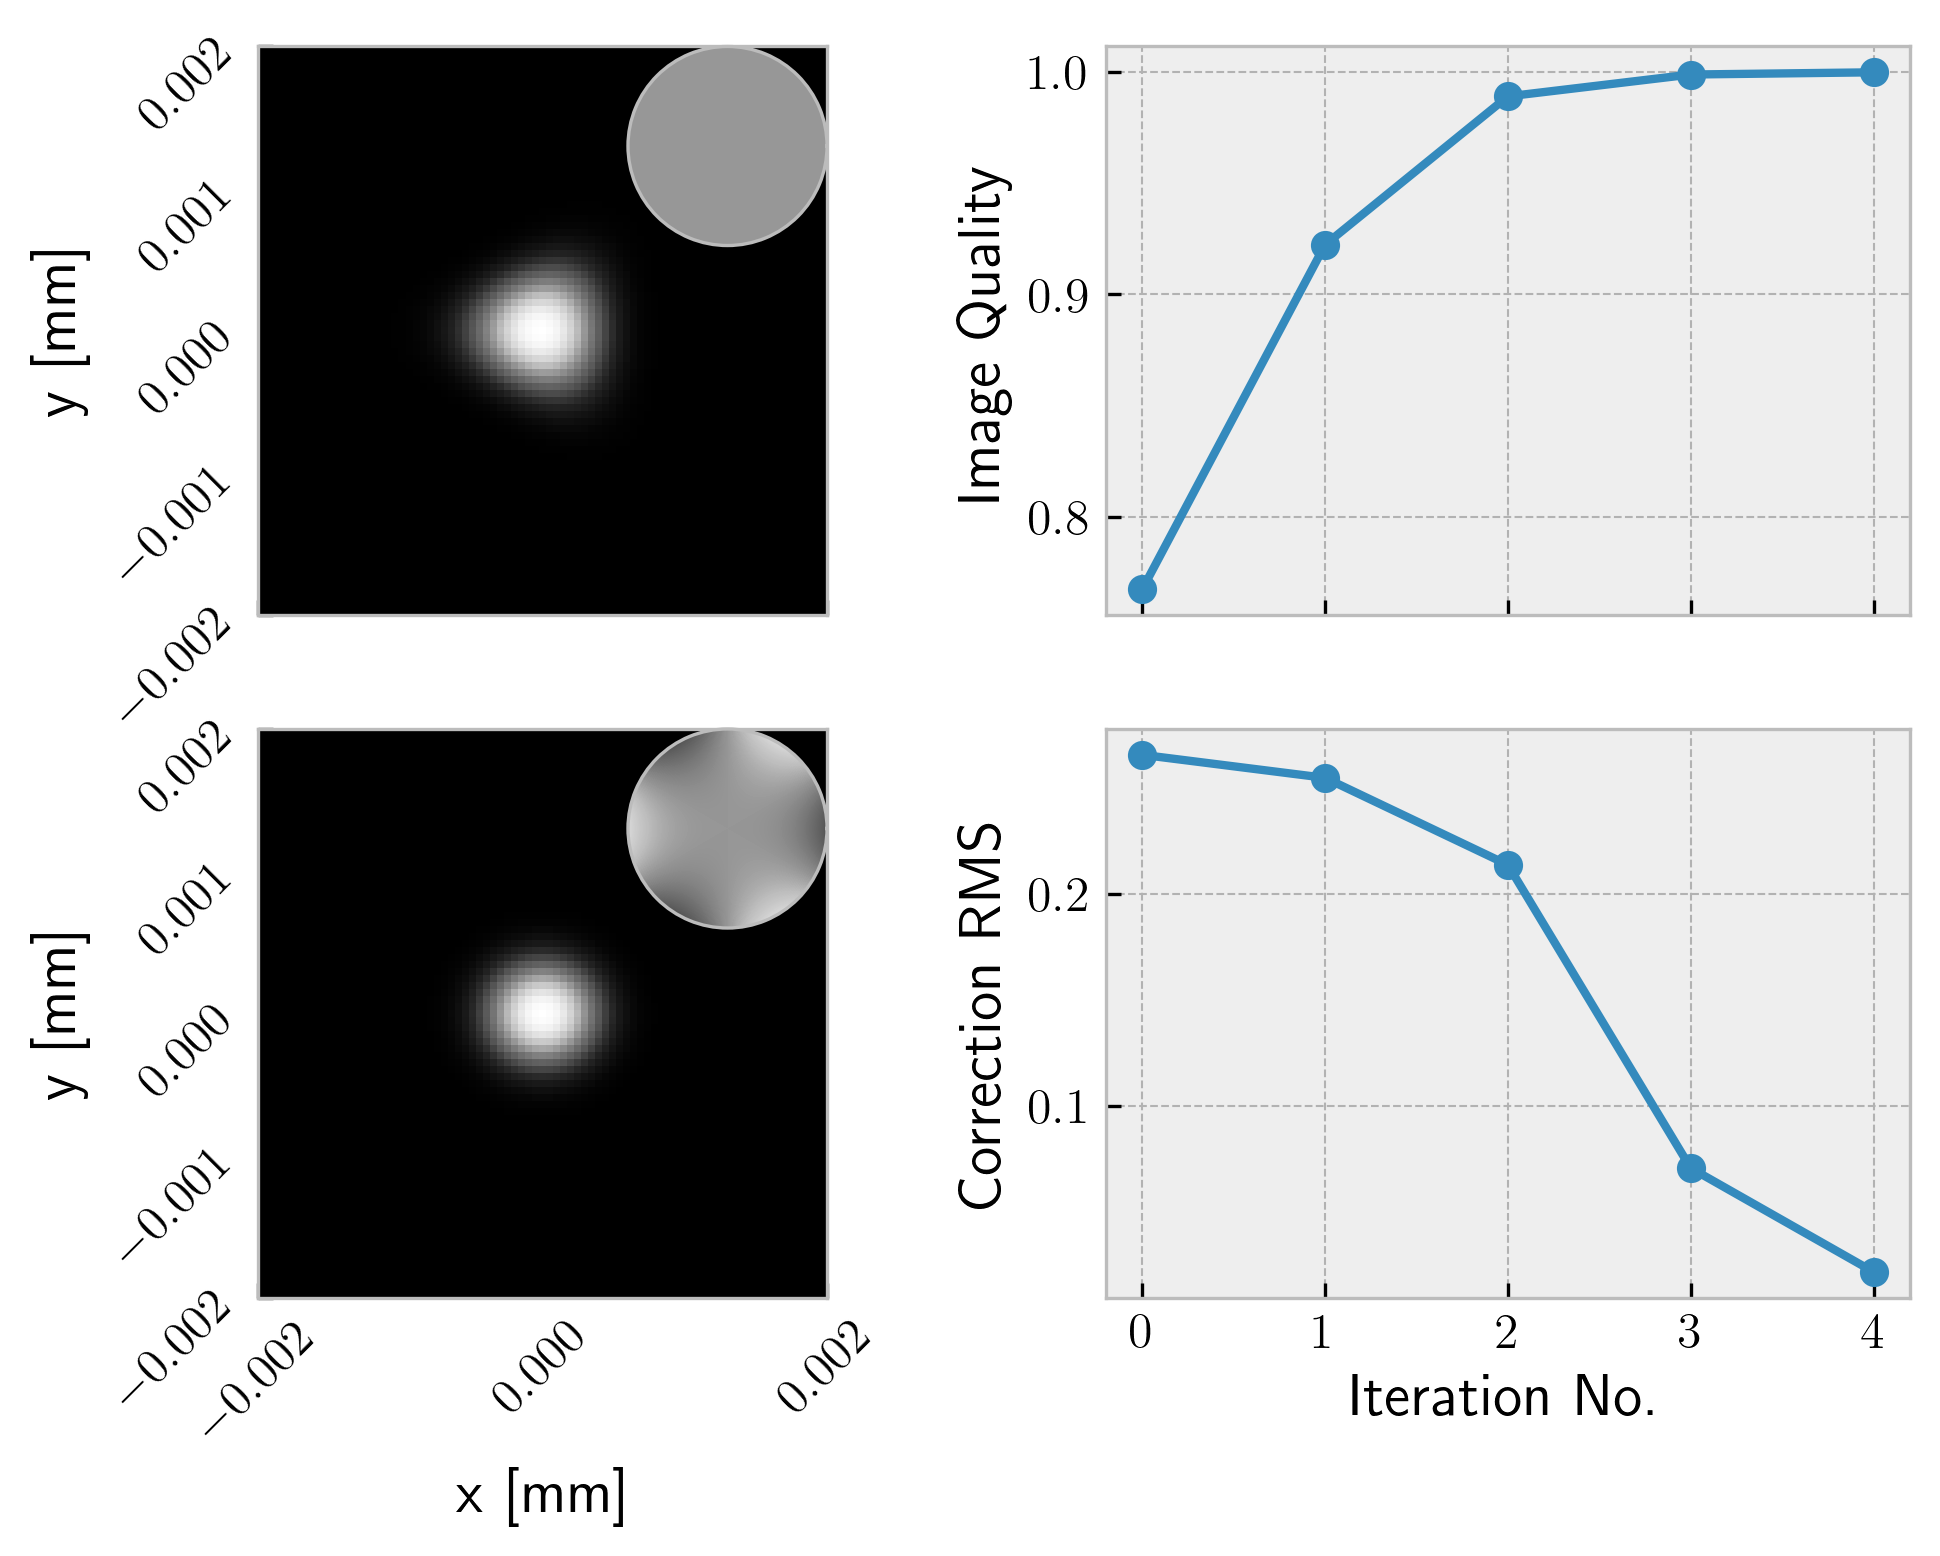

In [186]:
slm.produce_correction_graphic(quality_data, new_corrections)
plt.savefig("benchmarking_figures/single_bead_correct.png")


In [210]:
microscope = BH.Microscope(N_order, lambd, n, num_apt, length,
                           mag, fwhm_pupil, L_ffp, res, theta_grid_size)
x_img, y_img, cell_image = IH.cell(L_ffp * 3, res, 50, 177, pad_amt = 30)
innate_modes = np.array([[-2, 2]])
innate_strengths = np.array([0.5])

In [211]:
slm = BH.SLM(microscope, x_img, y_img, cell_image, innate_modes, innate_strengths)

In [212]:
slm_output_data, quality_data, new_corrections = slm.run_booth(4, zeta = 1)


===== Running Booth 2002 Modal AO Algorithm =====
No specific modes inputted. Assuming all modes should be corrected.
Original Aberration:
m=-2, n=2: 0.5
===== Iteration 1=====
Getting unbiased image at: m=-2, n=2: 0.0
Image Quality: 1.0
Applying biases: 0.2 waves
	===Optimizing m=-2, n=2===
	Exploring plus bias...
	Image Quality: 0.911
	Exploring minus bias...
	Image Quality: 1.085
	Evaluating next step...
	Stepping by -0.434 to -0.434
Applying corrections...
===== Iteration 2=====
Getting unbiased image at: m=-2, n=2: -0.434
Image Quality: 1.134
Applying biases: 0.16 waves
	===Optimizing m=-2, n=2===
	Exploring plus bias...
	Image Quality: 1.107
	Exploring minus bias...
	Image Quality: 1.132
	Evaluating next step...
	Stepping by -0.077 to -0.51
Applying corrections...
===== Iteration 3=====
Getting unbiased image at: m=-2, n=2: -0.51
Image Quality: 1.137
Applying biases: 0.128 waves
	===Optimizing m=-2, n=2===
	Exploring plus bias...
	Image Quality: 1.129
	Exploring minus bias...
	Im

<string>:9: RuntimeWarning: invalid value encountered in arcsin


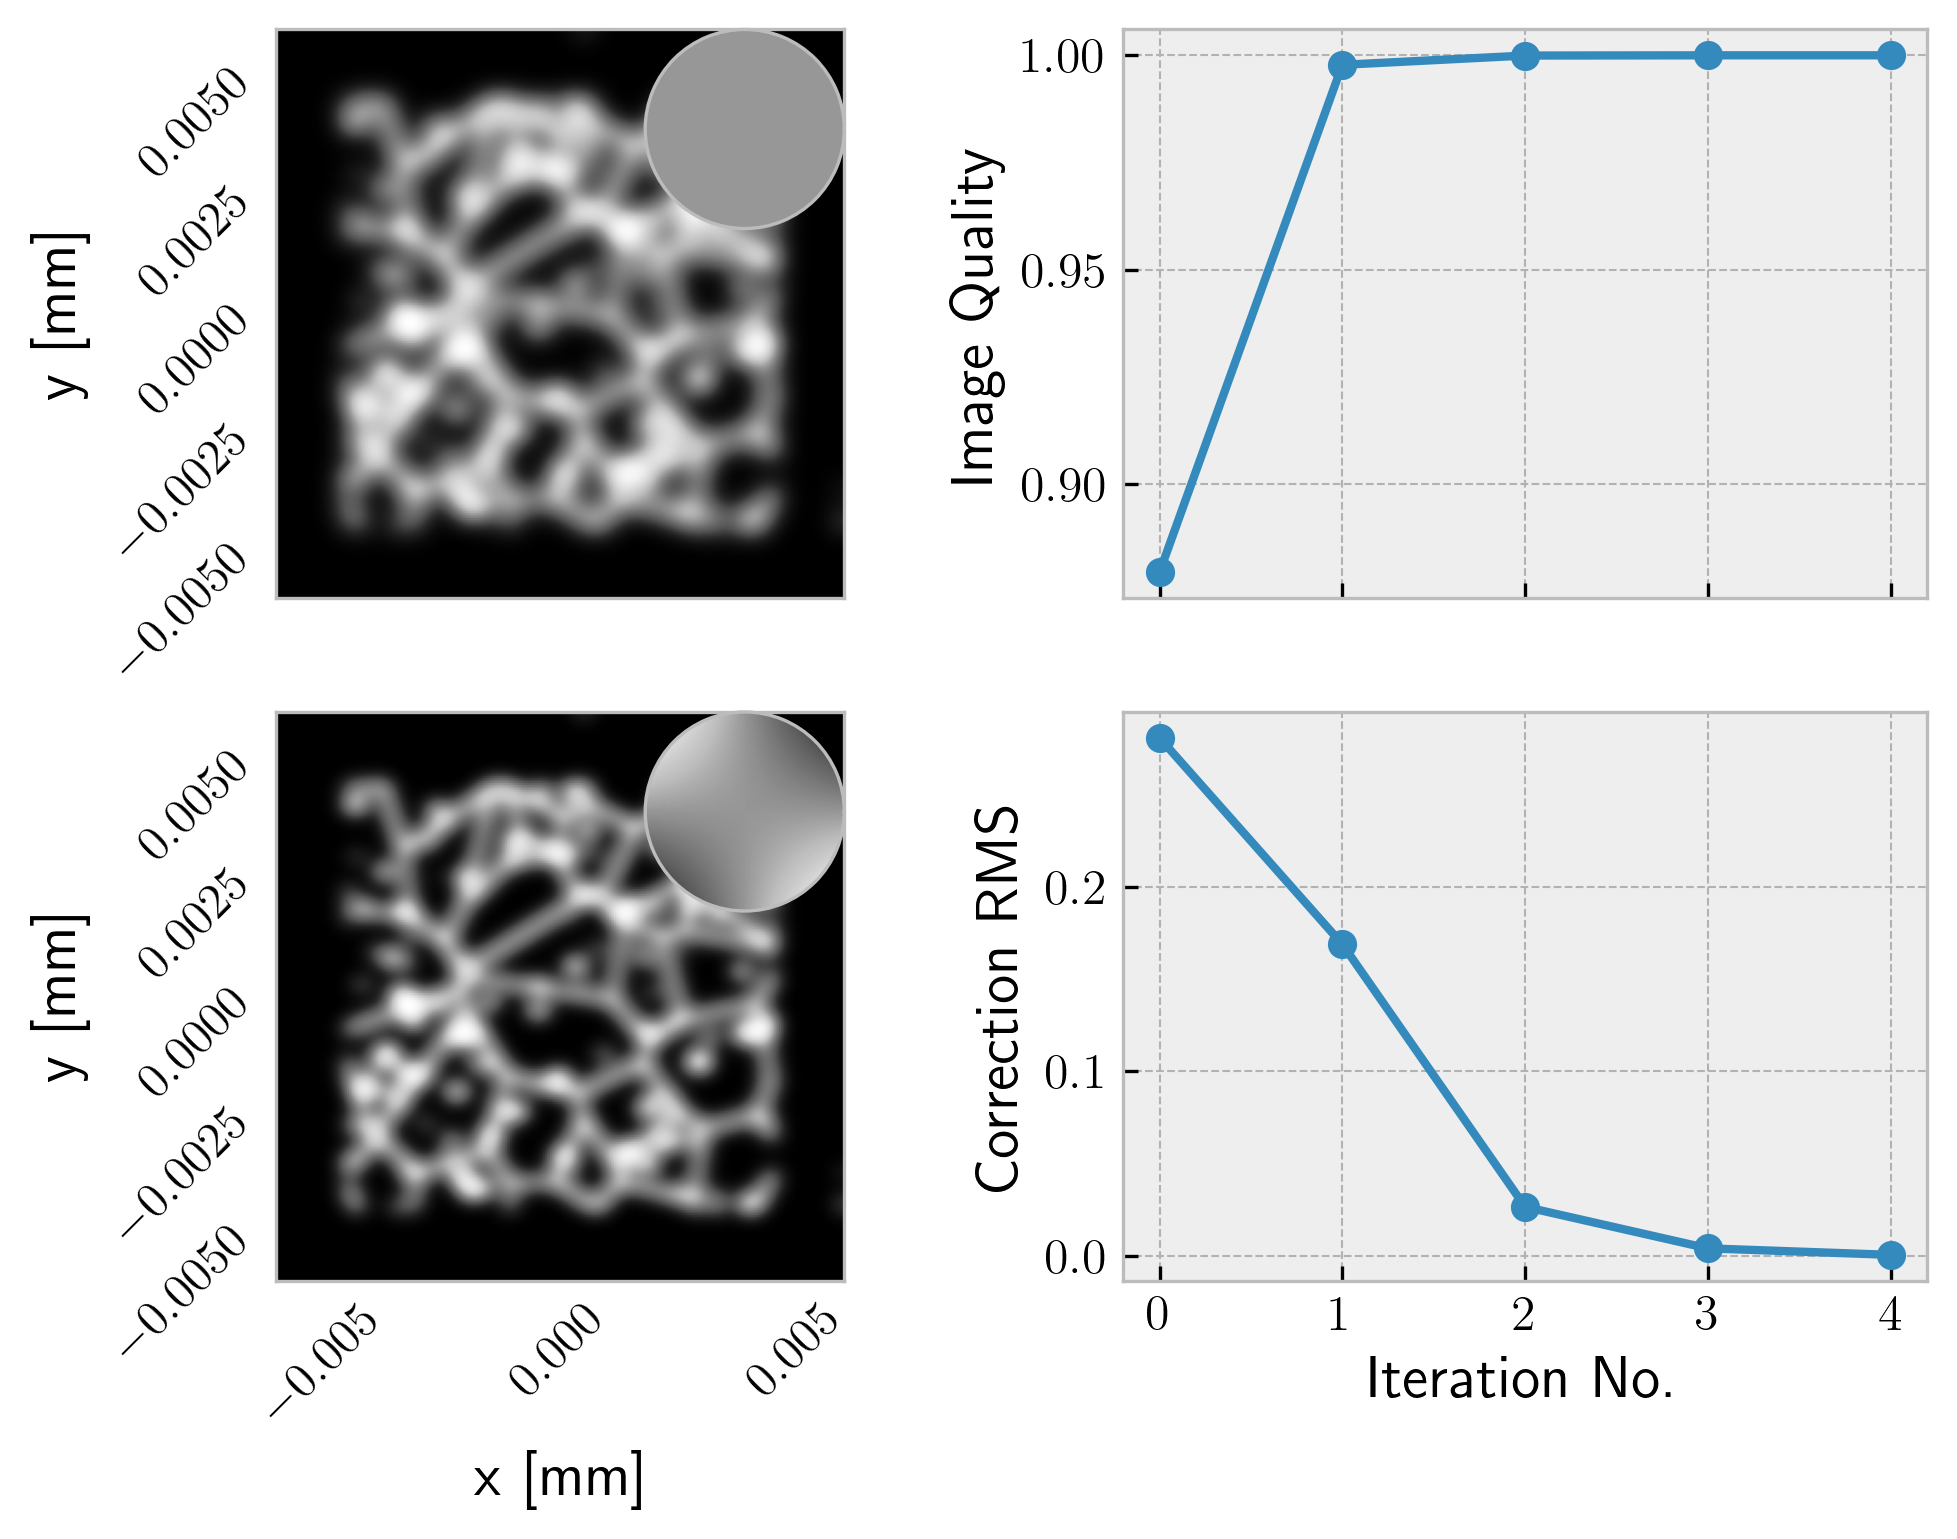

In [213]:
slm.produce_correction_graphic(quality_data, new_corrections)
plt.savefig("benchmarking_figures/one_mode_cell_correct.png", bbox_inches = "tight")

In [222]:
microscope = BH.Microscope(N_order, lambd, n, num_apt, length,
                           mag, fwhm_pupil, L_ffp, res, theta_grid_size)
x_img, y_img, cell_image = IH.cell(L_ffp * 3, res, 50, 192, pad_amt = 30)
innate_modes = np.array([[3,3], [-3,3], [0,2], [4,4]])
innate_strengths = np.array([0.4, -0.5, 0.25, -.4])

In [223]:
slm = BH.SLM(microscope, x_img, y_img, cell_image, innate_modes, innate_strengths)

In [224]:
slm_output_data, quality_data, new_corrections = slm.run_booth(7, zeta = 1)


===== Running Booth 2002 Modal AO Algorithm =====
No specific modes inputted. Assuming all modes should be corrected.
Original Aberration:
m=3, n=3: 0.4m=-3, n=3: -0.5m=0, n=2: 0.25m=4, n=4: -0.4
===== Iteration 1=====
Getting unbiased image at: m=3, n=3: 0.0m=-3, n=3: 0.0m=0, n=2: 0.0m=4, n=4: 0.0
Image Quality: 1.0
Applying biases: 0.2 waves
	===Optimizing m=3, n=3===
	Exploring plus bias...
	Image Quality: 0.99
	Exploring minus bias...
	Image Quality: 1.004
	Evaluating next step...
	Stepping by -0.033 to -0.033
Applying corrections...
	===Optimizing m=-3, n=3===
	Exploring plus bias...
	Image Quality: 1.009
	Exploring minus bias...
	Image Quality: 0.985
	Evaluating next step...
	Stepping by 0.06 to 0.06
Applying corrections...
	===Optimizing m=0, n=2===
	Exploring plus bias...
	Image Quality: 0.911
	Exploring minus bias...
	Image Quality: 1.016
	Evaluating next step...
	Stepping by -0.263 to -0.263
Applying corrections...
	===Optimizing m=4, n=4===
	Exploring plus bias...
	Image Qua

<string>:9: RuntimeWarning: invalid value encountered in arcsin


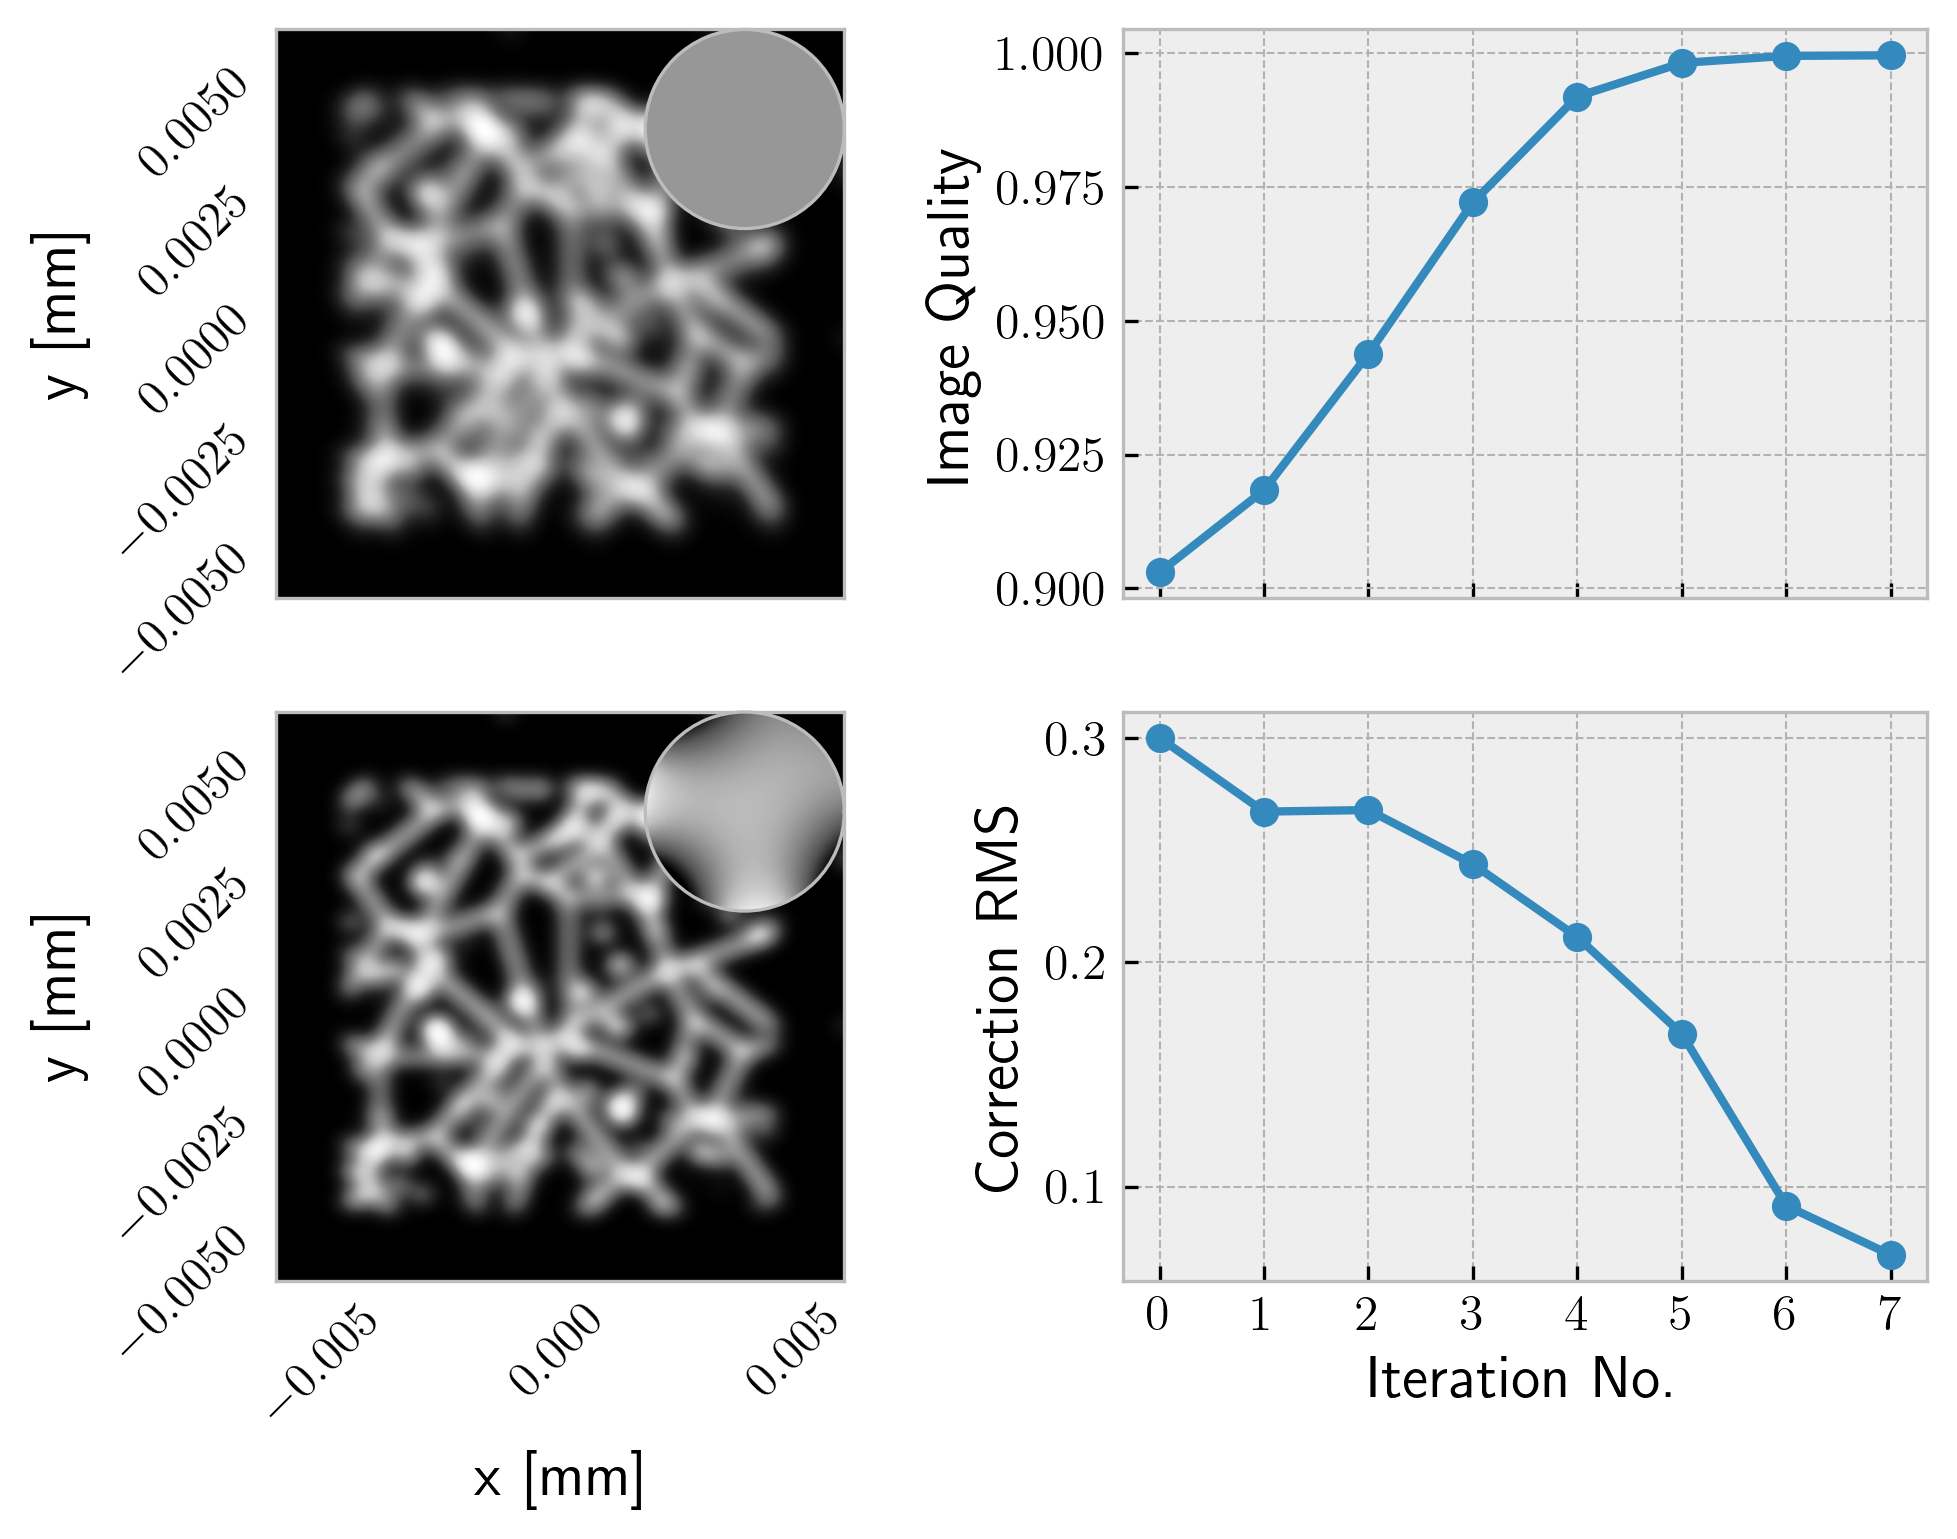

In [225]:
slm.produce_correction_graphic(quality_data, new_corrections)
plt.savefig("benchmarking_figures/many_mode_cell_correct.png", bbox_inches = "tight")

In [197]:
microscope = BH.Microscope(N_order, lambd, n, num_apt, length,
                           mag, fwhm_pupil, L_ffp, res, theta_grid_size)
x_img, y_img, cell_image = IH.cell(L_ffp * 3, res, 50, 185, pad_amt = 30)

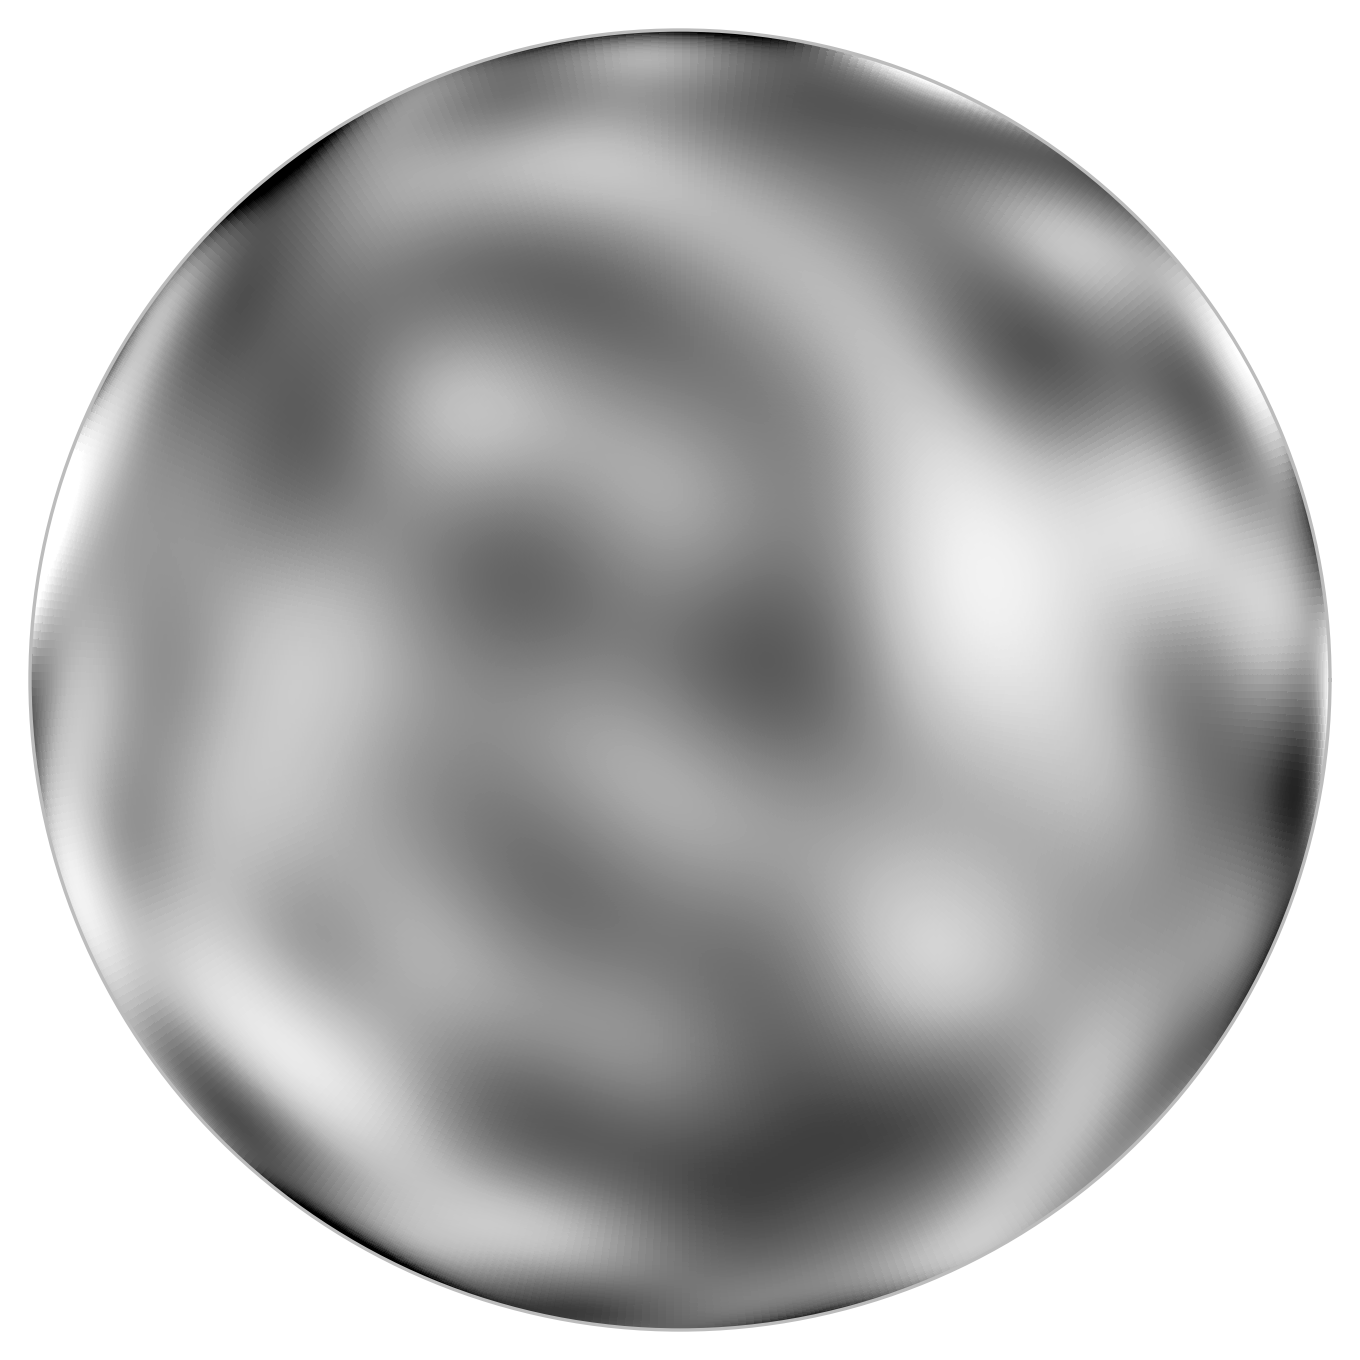

In [198]:
innate_modes, innate_strengths = ZH.generate_random_aberration(57, 15, 0.5)
z_map = ZH.create_zernike_function(innate_modes, innate_strengths, microscope.alpha)
PH.zernike_plot(z_map, microscope.alpha, "arb_aberr")

In [203]:
slm = BH.SLM(microscope, x_img, y_img, cell_image, innate_modes, innate_strengths)

In [204]:
correct_modes = [[2,2],
                 [0,2],
           [-2,2],
           [1,3],
           [-1,3],
           [3,3],
           [-3,3],
           [0,4],
           [2,4],
           [-2,4],
           [4,4],
           [-4,4]]

In [205]:
slm_output_data, quality_data, new_corrections = slm.run_booth(10, zeta = 0.5, corrected_modes = correct_modes)


===== Running Booth 2002 Modal AO Algorithm =====
Noted that only some modes should be corrected.
Original Aberration:
m=-2, n=2: 0.13m=0, n=2: -0.022m=2, n=2: 0.241m=-3, n=3: -0.092m=-1, n=3: -0.061m=1, n=3: -0.198m=3, n=3: -0.041m=-4, n=4: 0.113m=-2, n=4: -0.105m=0, n=4: -0.081m=2, n=4: -0.156m=4, n=4: -0.009m=-5, n=5: 0.201m=-3, n=5: 0.206m=-1, n=5: 0.022m=1, n=5: 0.065m=3, n=5: -0.192m=5, n=5: -0.111m=-6, n=6: 0.022m=-4, n=6: -0.003m=-2, n=6: -0.063m=0, n=6: 0.121m=2, n=6: 0.188m=4, n=6: 0.036m=6, n=6: 0.011m=-7, n=7: 0.069m=-5, n=7: -0.099m=-3, n=7: 0.151m=-1, n=7: 0.135m=1, n=7: 0.095m=3, n=7: -0.162m=5, n=7: 0.102m=7, n=7: 0.18m=-8, n=8: -0.002m=-6, n=8: -0.107m=-4, n=8: 0.056m=-2, n=8: 0.042m=0, n=8: -0.103m=2, n=8: 0.154m=4, n=8: 0.031m=6, n=8: -0.058m=8, n=8: -0.124m=-9, n=9: 0.066m=-7, n=9: -0.16m=-5, n=9: 0.057m=-3, n=9: -0.112m=-1, n=9: 0.04m=1, n=9: -0.115m=3, n=9: -0.066m=5, n=9: 0.048m=7, n=9: 0.036m=9, n=9: 0.088m=-10, n=10: 0.03m=-8, n=10: -0.094m=-6, n=10: 0.124m=-4,

<string>:9: RuntimeWarning: invalid value encountered in arcsin


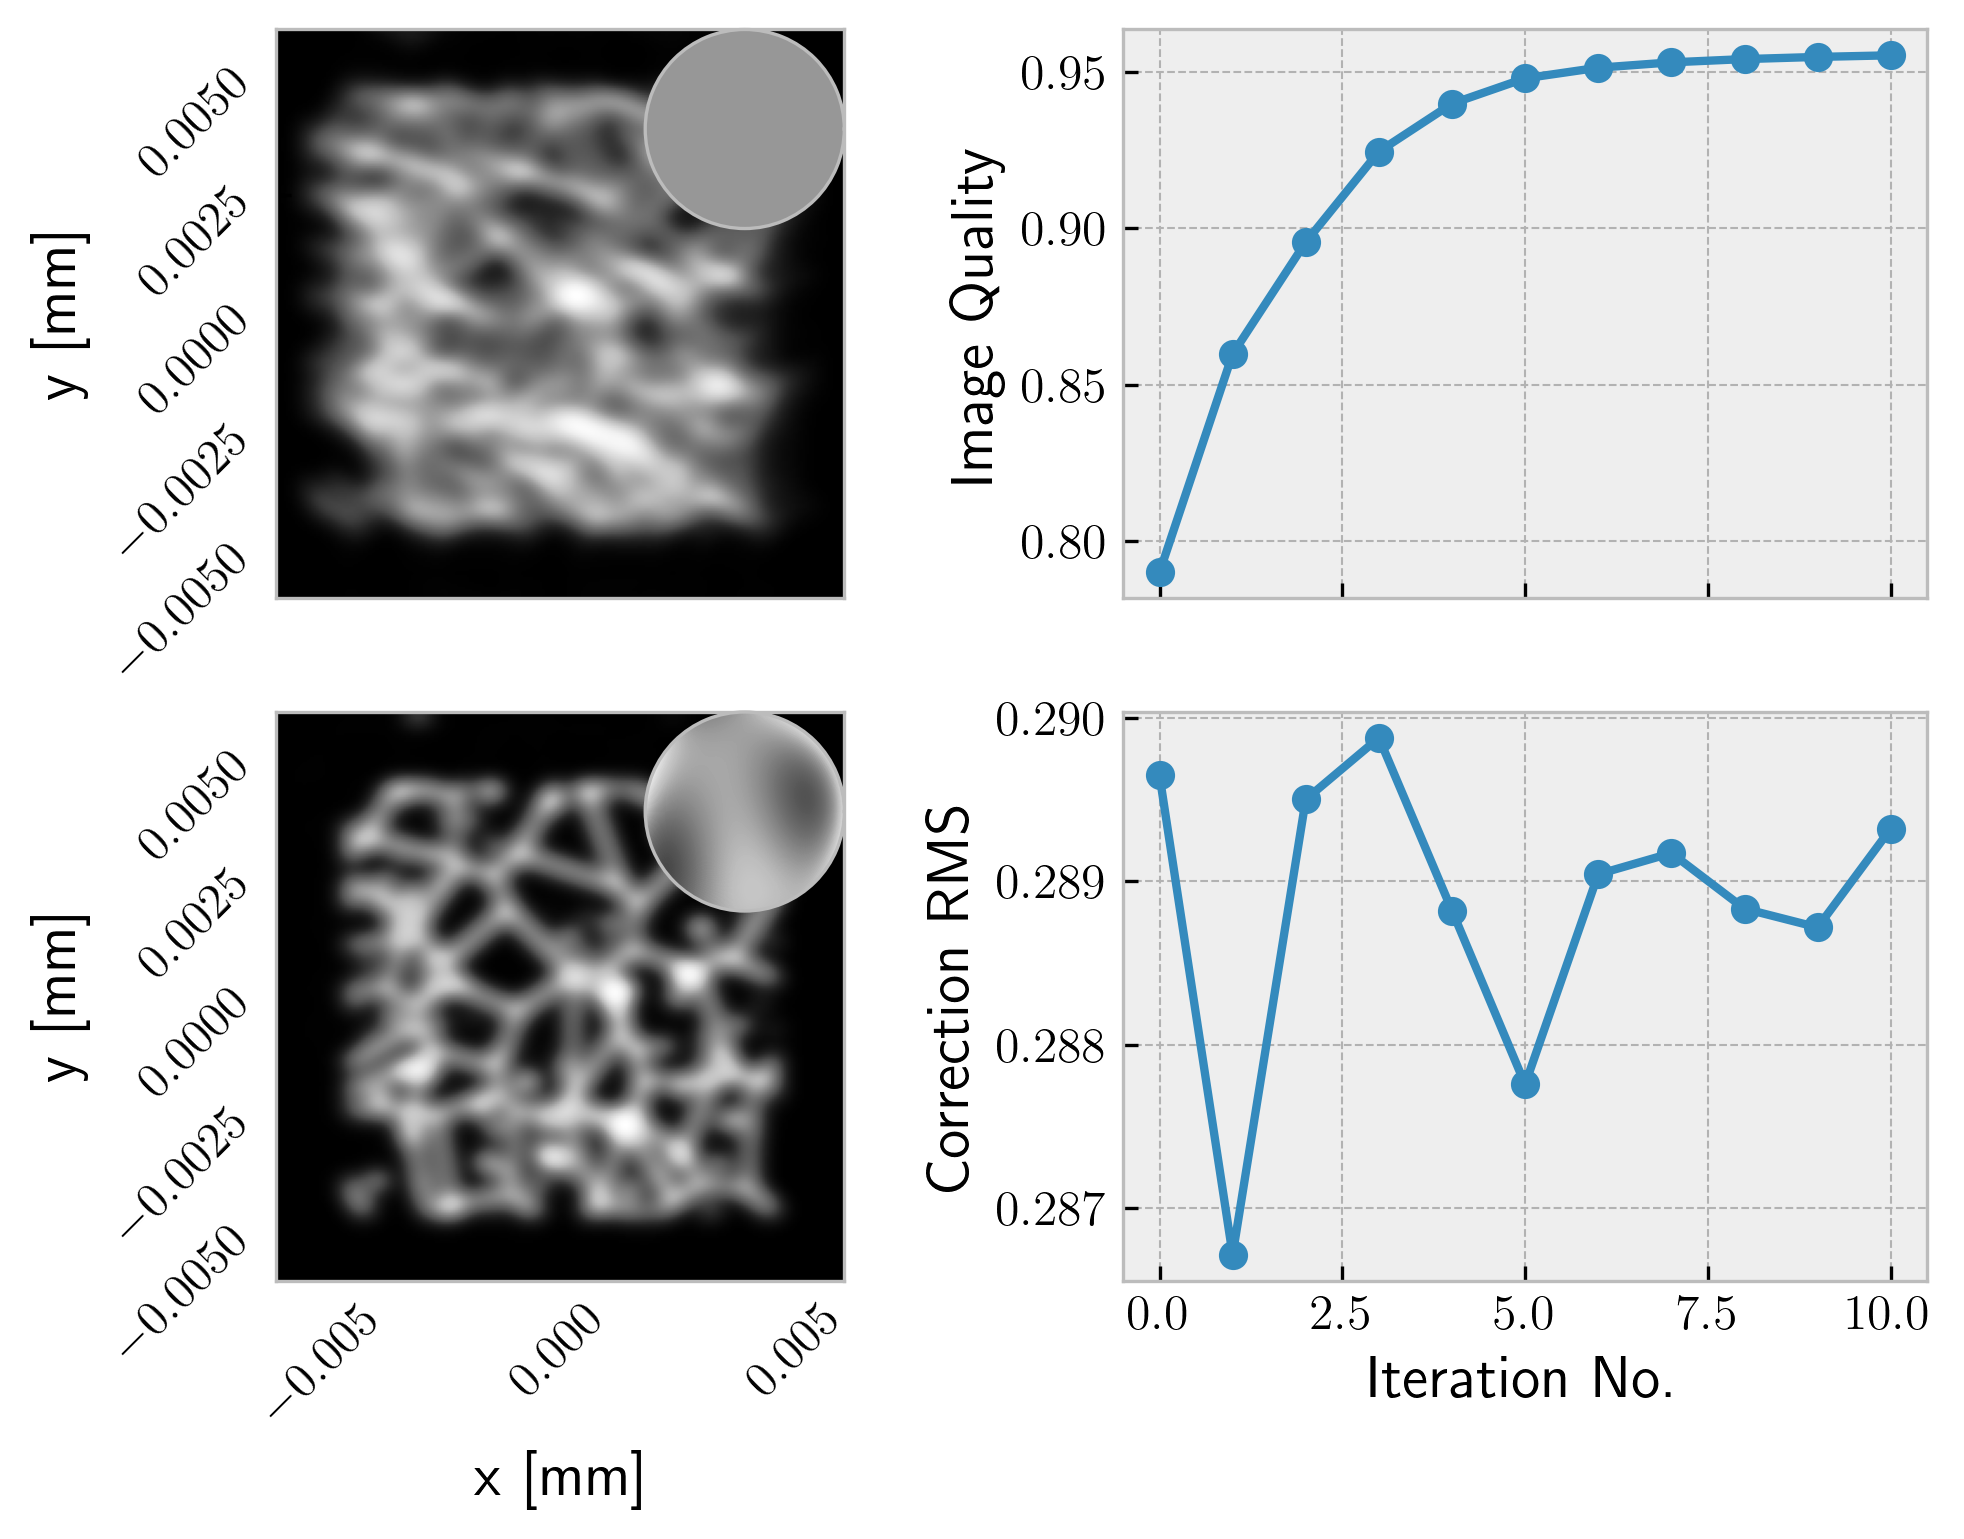

In [206]:
slm.produce_correction_graphic(quality_data, new_corrections)
plt.savefig("benchmarking_figures/random_cell_correct.png", bbox_inches = "tight")